In [1]:
#TMDB Extract

In [2]:
from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies(50)

len(data)
data[0]

Fetching pages: 50/50 | Movies: 1000 | Time: 12.7s


{'adult': False,
 'backdrop_path': '/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg',
 'genre_ids': [16, 10751, 14],
 'id': 129,
 'original_language': 'ja',
 'original_title': '千と千尋の神隠し',
 'overview': 'A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.',
 'popularity': 30.4319,
 'poster_path': '/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg',
 'release_date': '2001-07-20',
 'title': 'Spirited Away',
 'video': False,
 'vote_average': 8.534,
 'vote_count': 18176}

Basic Transform

In [3]:
from src.etl.transform import Transform

df = Transform.to_dataframe(data)

print(df.shape)
df.head()
df.describe()

Valid rows: 1000
Invalid rows skipped: 0
(1000, 9)


,movie_id,rating,popularity,release_year
count,1.000000e+03,1000.000000,1000.000000,999.000000
mean,2.278676e+05,6.759300,8.884692,2006.310310
std,2.992118e+05,0.718143,29.118046,16.144941
min,2.200000e+01,5.100000,0.007300,1922.000000
25%,1.026700e+04,6.200000,4.684525,1999.000000
50%,3.832000e+04,6.800000,6.114550,2010.000000
75%,4.307302e+05,7.300000,8.864900,2018.000000
max,1.311031e+06,8.500000,828.462100,2026.000000


In [4]:
df.isnull().sum()

movie_id        0
title           0
release_date    1
rating          0
popularity      0
genre_ids       0
genres          0
category        0
release_year    1
dtype: int64

In [5]:
df[df["release_date"].isnull()]

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year
666,670355,Return,None,6.4,0.0929,"[18, 14]","Drama, Fantasy",Fantasy Epic,NaN


<Axes: title={'center': 'Movies per Year'}, xlabel='release_year'>

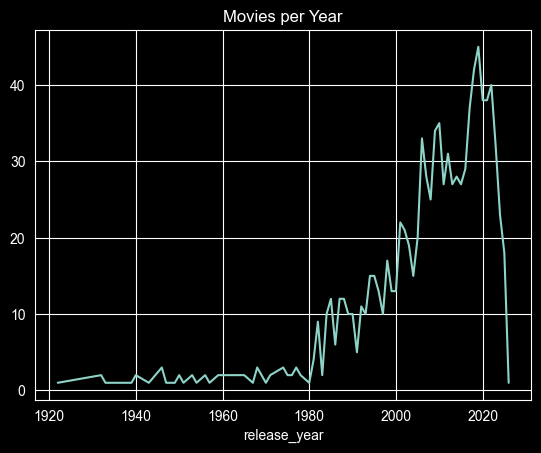

In [6]:
df.groupby("release_year").size().plot(title="Movies per Year")

In [7]:
df.sort_values(by="rating", ascending=False).head(10)[["title", "rating"]]

,title,rating
2,The Lord of the Rings: The Return of the King,8.5
1,The Green Mile,8.5
0,Spirited Away,8.5
3,The Lord of the Rings: The Fellowship of the Ring,8.4
6,Howl's Moving Castle,8.4
5,The Lord of the Rings: The Two Towers,8.4
4,A Dog's Will,8.4
7,Chainsaw Man - The Movie: Reze Arc,8.3
9,The Legend of Hei,8.3
10,Violet Evergarden: The Movie,8.3


In [8]:
import os
from dotenv import load_dotenv
import duckdb
from src.utils.paths import project_path

load_dotenv()
DUCKDB_PATH_ENV = os.getenv("DUCKDB_PATH", "data/db/movies.duckdb")
DB_PATH = project_path(DUCKDB_PATH_ENV)
print("Resolved DuckDB path:", DB_PATH)

# Connect and query
with duckdb.connect(DB_PATH) as con:
    df_db = con.execute("SELECT * FROM movies").fetchdf()
    df_db.head()

Resolved DuckDB path: C:\Users\strom\code\Grupp7_Datavisualisering_DE_UX\data\db\movies.duckdb


##Upcoming movies

In [9]:
from datetime import datetime

today = datetime.today().date()

unreleased = df[df["release_date"] > today]
unreleased.head()

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year


Test case för top5 of movies

In [10]:
from src.etl.extract import Extract
from src.services.tmdb_service import TMDBService

service = TMDBService()
movies = extractor.fetch_movies(pages=25)

# Only enrich top X
for movie in movies[:10]:
    details, status = service.get_movie_details(movie["id"])
    print(details)

Fetching pages: 25/25 | Movies: 500 | Time: 6.4s
movie_id=129 title='Spirited Away' original_title='千と千尋の神隠し' original_language='ja' overview='A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.' tagline='Beyond the tunnel was a mysterious town.' status='Released' homepage='https://gkids.com/films/spirited-away' imdb_id='tt0245429' runtime=125 budget=19000000 revenue=274925095 popularity=30.431900024414062 vote_average=8.534000396728516 vote_count=18176 release_date=None adult=False video=False poster_path='/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg' backdrop_path='/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg' collection_id=None collection_name=None origin_country=None genres=None director='Hayao Miyazaki' last_updated=Timestamp('2026-04-20 18:14:09.488695')
movie_id=497 title='The Green Mile' original_title='The Green Mile' original_language='en' overview="A 

In [11]:
from src.repository.movie_repository import MovieRepository

with MovieRepository(DB_PATH) as repo:
    print(repo.conn.execute("SHOW TABLES").fetchall())


[('genres',), ('movie_cast',), ('movie_crew',), ('movie_details',), ('movie_genres',), ('movie_origin_countries',), ('movies',), ('production_companies',), ('production_countries',), ('spoken_languages',)]


In [12]:
for movie in movies[:1]:
    details, status = service.get_movie_details(movie["id"])

    print(
        details.movie_id,
        details.runtime,
        details.director
    )

129 125 Hayao Miyazaki


Grab from the database so we can include cast and crew.

In [13]:
# top 5 from the cached database including full cast and crew
for movie in movies[:5]:
    details = service.repo.get_full_movie_details(movie["id"])
    print(details)

{'movie': {'movie_id': 129, 'title': 'Spirited Away', 'original_title': '千と千尋の神隠し', 'original_language': 'ja', 'overview': 'A young girl, Chihiro, becomes trapped in a strange new world of spirits. When her parents undergo a mysterious transformation, she must call upon the courage she never knew she had to free her family.', 'tagline': 'Beyond the tunnel was a mysterious town.', 'status': 'Released', 'homepage': 'https://gkids.com/films/spirited-away', 'imdb_id': 'tt0245429', 'runtime': 125, 'budget': 19000000, 'revenue': 274925095, 'popularity': 30.431900024414062, 'vote_average': 8.534000396728516, 'vote_count': 18176, 'release_date': None, 'adult': False, 'video': False, 'poster_path': '/39wmItIWsg5sZMyRUHLkWBcuVCM.jpg', 'backdrop_path': '/dyJvKsNs2KP8qQnAXbRwDjblViy.jpg', 'collection_id': None, 'collection_name': None, 'origin_country': None, 'genres': None, 'director': 'Hayao Miyazaki', 'last_updated': Timestamp('2026-04-20 18:14:09.488695')}, 'cast':     actor_id          actor_